# 02 — Label Validation

**The Phase 1 gate.** Everything downstream inherits this label, and nothing downstream
rescues it. The question is not "is the label good" — it is *what exactly does it measure, what
may I therefore claim, and is there anything better available*.

The label is the **blocked fraction over T → T+90**: for each listing, the share of its first 90
forward calendar days that are unavailable, anchored at that listing's own
`T = min(calendar.date)`. It is a **demand proxy**, never bookings — the Inside Airbnb calendar
is forward-looking availability, and blocked days include personal use, maintenance and seasonal
closure.

## The conclusion, stated up front

So the sections below read as evidence for a claim rather than a retreat from one:

> The label is a **two-stage signal**. Listing establishment gets a listing into contention;
> review quality orders it within that cohort. It is **not** a measure of demand among
> otherwise-comparable listings.

It is used anyway, for three reasons this notebook establishes in order:

1. **It is computed correctly** — an independently shipped column reproduces it to 99.96 %+ (§1).
2. **It points the right way, consistently** — every review signal correlates positively, in
   every city, before and after filtering: 54 of 54 combinations, no exceptions (§3).
3. **Every alternative target is worse** — and measurably so. The obvious substitutes are
   0.76–0.81 correlated with raw review counts; this label is 0.18–0.31 (§5). The
   establishment confound that §4 measures is real, and it is *smaller here than in anything
   else available*.

What stays open, and is named rather than buried: the correlations are modest in absolute terms,
blocked ≠ booked cannot be resolved with this data, and whether the label carries much beyond
listing age and rating is settled by Phase 3's frozen baseline, not by this notebook.

## 0. The frame

One build, used by every section, in the order the pipeline runs it: label → filters → price →
grades. `occupancy_label` owns **T**; `filters` owns row removal; `reviews_in_window` takes T
rather than re-deriving it, so a window used in validation is computed exactly as the one used in
training. Price is imputed here only because §6 needs a price tier to argue against; nothing
about the label or its grades depends on it.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from rental_ranking import eda
from rental_ranking.data.filters import filter_listings, is_dormant
from rental_ranking.data.paths import PROCESSED_DIR
from rental_ranking.features.groups import capacity_tier
from rental_ranking.features.label import (
    assign_grades,
    crosscheck_availability_90,
    occupancy_label,
)
from rental_ranking.features.price import impute_price
from rental_ranking.features.reviews import reviews_in_window, same_season_last_year

pd.set_option("display.width", 120)

listings_df = pd.read_parquet(PROCESSED_DIR / "listings.parquet")
calendar_df = pd.read_parquet(PROCESSED_DIR / "calendar.parquet")
reviews_df = pd.read_parquet(PROCESSED_DIR / "reviews.parquet", columns=["listing_id", "date"])

labels = occupancy_label(calendar_df)
labelled = listings_df.merge(labels, left_on="id", right_index=True, how="inner")
ranked, filter_counts = filter_listings(labelled)
ranked, price_rungs = impute_price(ranked)
ranked["capacity_tier"] = capacity_tier(ranked)

CITIES = ["thessaloniki", "athens", "crete"]
COHORTS = ["never reviewed", "new this year", "established"]
LABEL = "blocked_fraction_90"
QUERY_GROUP = ["city", "neighbourhood_cleansed", "room_type", "capacity_tier"]

print(f"{len(labelled):,} listings labelled  ->  {len(ranked):,} ranked")

46,635 listings labelled  ->  44,684 ranked


**What the table below shows.** One row per city, one column per rule. `inactive` counts
listings with no reviews ever *and* a fully blocked label window; `long_term` counts
`minimum_nights > 30`; `dormant` counts listings blocked for ≥ 99 % of their **entire** forward
calendar — withdrawn, not booked, and defined over the whole year so a summer-only operator can
never be caught; `extreme_price` counts prices above 20× their own structural stratum's median —
data errors, not outliers. `multi_rule` is the overlap, reported rather than absorbed so the
per-rule counts stay independent. `removed` and `kept` reconcile to `n`.

Note for later: two of the four rules (`inactive`, `dormant`) read the calendar itself, so
filtering mechanically moves the label's correlations. §2 therefore cross-examines `dormant`
against the review file, and §3 reports every correlation both before and after filtering.

In [2]:
filter_counts

,n,inactive,long_term,dormant,extreme_price,multi_rule,removed,kept
city,,,,,,,,
athens,14337,101,1,2,14,0,118,14219
crete,27333,523,43,1279,7,295,1556,25777
thessaloniki,4965,75,25,222,4,48,277,4688


## 1. Is the label computed correctly?

Before asking what the label *means*, rule out that it is simply wrong. Inside Airbnb ships
`availability_90` — the same quantity, computed by them at scrape time, from their own pipeline.
It is on the feature blocklist and never reaches a model; this is the one thing it is for.

**What the table below shows.** Per city: how many listings were compared, the share whose
derived available-night count matches the shipped column **exactly**, how many disagree, and the
mean absolute gap in nights.

In [3]:
crosscheck_availability_90(labels, listings_df)

,n,exact_agreement,n_mismatched,mean_abs_diff
city,,,,
athens,14337,0.999861,2,0.009765
crete,27333,0.999744,7,0.006915
thessaloniki,4965,0.999597,2,0.031017


**Agreement is 99.96–99.99 %, with 11 disagreeing listings in total and a mean gap under
0.04 nights.** The residual is scrape timing: their figure is computed at the moment of the
scrape, ours is anchored on the calendar's own first date, and 26 listings have a calendar that
starts a day or two before their listings row was written.

This does not prove the label measures demand. It proves the window, the anchor and the counting
are right — which removes an entire class of objection before the harder questions start.

## 2. What shape is the label?

`blocked_fraction_90 = blocked_days / 90`, so it has exactly **91 attainable values**. A
histogram would bin across them and smear the endpoints into their neighbours — which is
precisely what needs looking at.

Terms used from here on:

- **Blocked day** — a calendar row with `available = False`. Not a booking.
- **Atom** — a point mass at exactly 0.0 or exactly 1.0, as opposed to the continuum between.
- **Interior** — every listing strictly between the two atoms.

**What the two tables below show.** Per city, how the label's mass splits three ways: sitting
exactly at 0.0 (nothing blocked), somewhere in the interior, or exactly at 1.0 (nothing
bookable). The first table is the labelled population, the second is after filtering — the pair
shows what the filters removed.

In [4]:
def spike_table(frame: pd.DataFrame) -> pd.DataFrame:
    g = frame.groupby("city")[LABEL]
    return pd.DataFrame(
        {
            "n": g.size(),
            "at_0.0": g.apply(lambda s: s.eq(0).sum()),
            "at_0.0_%": (g.apply(lambda s: s.eq(0).mean()) * 100).round(2),
            "interior_%": (
                g.apply(lambda s: s.between(0, 1, inclusive="neither").mean()) * 100
            ).round(2),
            "at_1.0": g.apply(lambda s: s.eq(1).sum()),
            "at_1.0_%": (g.apply(lambda s: s.eq(1).mean()) * 100).round(2),
        }
    ).reindex(CITIES)


display(spike_table(labelled).style.set_caption("before filters"))
display(spike_table(ranked).style.set_caption("after filters"))

,n,at_0.0,at_0.0_%,interior_%,at_1.0,at_1.0_%
city,,,,,,
thessaloniki,4965,332,6.690000,85.680000,379,7.630000
athens,14337,683,4.760000,91.890000,480,3.350000
crete,27333,517,1.890000,90.320000,2130,7.790000


,n,at_0.0,at_0.0_%,interior_%,at_1.0,at_1.0_%
city,,,,,,
thessaloniki,4688,331,7.060000,90.120000,132,2.820000
athens,14219,680,4.780000,92.600000,372,2.620000
crete,25777,503,1.950000,95.470000,664,2.580000


**What the figure below shows.** Every one of the 91 attainable label values on the x-axis,
against the share of a city's listings holding that value. One line per city; the two dots mark
the atoms, annotated with their share. Because every value is plotted, there is no bin width to
argue about — a point mass appears as the vertical jump it is.

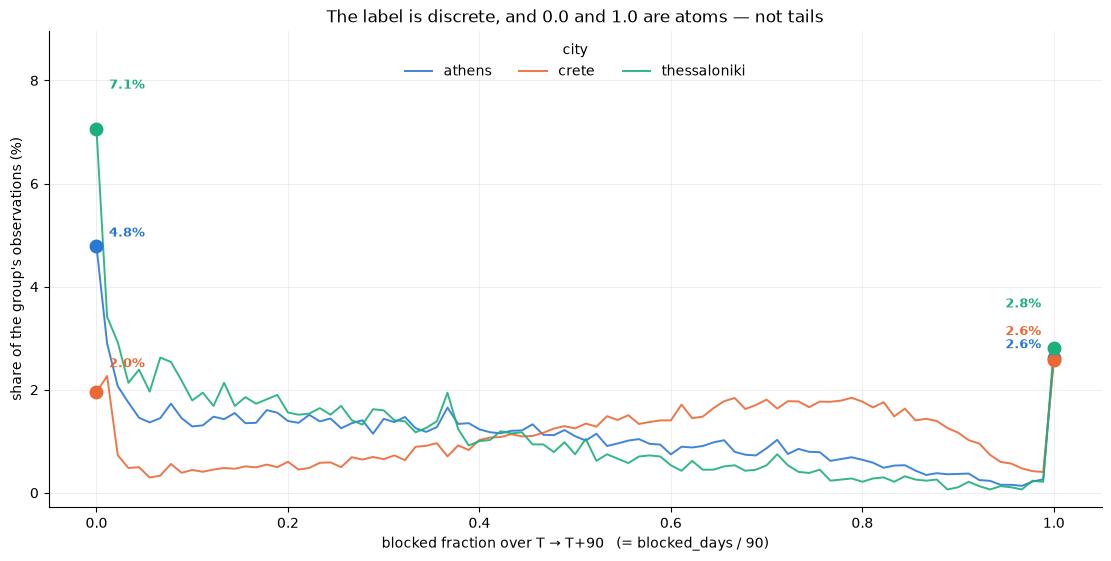

In [5]:
ranked["blocked_days"] = 90 - ranked["avail_90"]

eda.plot_discrete_distribution(
    ranked["blocked_days"],
    ranked["city"],
    levels=range(91),
    highlight=(0, 90),
    x_divisor=90,
    title="The label is discrete, and 0.0 and 1.0 are atoms — not tails",
    xlabel="blocked fraction over T → T+90   (= blocked_days / 90)",
);

**What the figure below shows.** The same three groups — exactly 0.0, interior, exactly 1.0 —
but now asking *who is in them*. Each bar is normalised to 100 %, split by listing age cohort,
one panel per city. Bucket sizes differ by orders of magnitude, so raw counts would let the
interior hide the composition of the two atoms.

Cohorts come from `first_review` against T: never reviewed, first reviewed within the last year,
or established. That is the only listing-age proxy available — `host_since` is 100 % null in all
three cities.

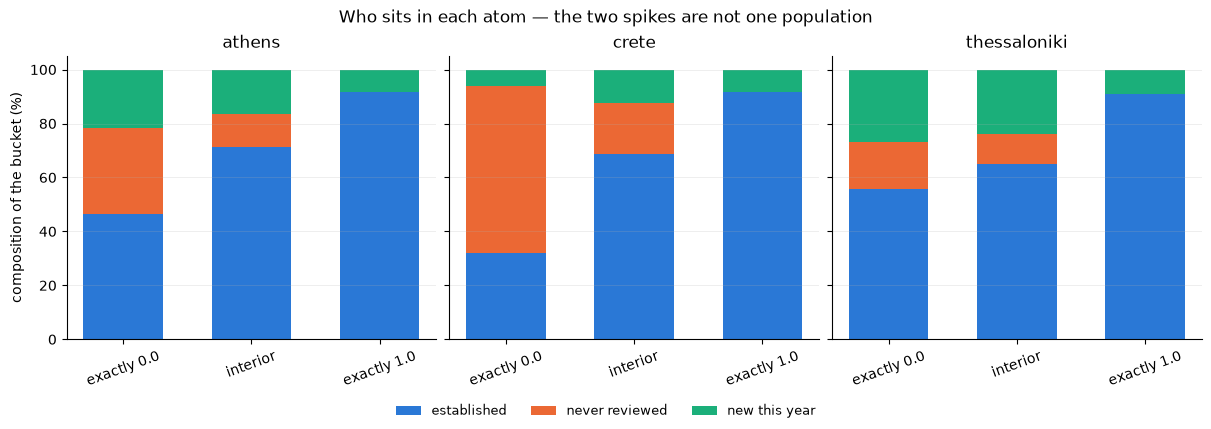

In [6]:
ranked["bucket"] = pd.cut(
    ranked[LABEL], [-0.01, 0.0001, 0.9999, 1.01], labels=["exactly 0.0", "interior", "exactly 1.0"]
)

age = ranked["T"] - ranked["first_review"]
ranked["cohort"] = np.where(
    ranked["first_review"].isna(),
    "never reviewed",
    np.where(age < pd.Timedelta(days=365), "new this year", "established"),
)

eda.plot_group_composition(
    ranked["bucket"],
    ranked["cohort"],
    ranked["city"],
    title="Who sits in each atom — the two spikes are not one population",
);

Three readings, all of which matter later.

**The atoms are not two ends of one distribution — they are different populations.** The 0.0
atom skews cold-start (62 % never-reviewed in Crete); the 1.0 atom is ~91 % established in every
city. A label of 0.0 can therefore mean *undiscovered* as easily as *unwanted*, and §6 shows what
that costs when the label is cut into grades.

**Season is visible in the shape.** The 0.0 atom is 3.6× smaller in Crete than Thessaloniki and
2.5× smaller than Athens, and Crete's interior mass sits far to the right — a broad hump centred
near 0.7 — while the other two decay from the left. A July–September window in a seasonal island
market looks exactly like this, which is weak evidence that the label is tracking something real
rather than noise.

**The filters rewrote the 1.0 atom, and that was the point.** Before filtering, the atom held
7.6 % of Thessaloniki and 7.8 % of Crete but only 3.4 % of Athens; after it, the three cities
agree to within a quarter of a point (2.6–2.8 %). Two rules each removed a different population:
`inactive` took the never-reviewed corner, and `dormant` took 1,503 listings blocked for their
*entire* forward year. Because that rule reads the calendar — and §3 will show that removing its
catch raises every correlation — it gets cross-examined below rather than taken on trust. What
survives at 1.0 — 132 / 372 / 664 listings — every one carries a review history *and* reopens
later in its own calendar year, which is what a booked-out summer listing looks like and a dead
one does not.

Before leaving §2, the promised cross-examination. `dormant` removed 1,503 listings, most of
them from the label's maximum, and §3 will show that doing so raises every correlation — so the
notebook owes a demonstration that the catch is withdrawn stock, not merely the points that
depressed rho.

**What the table below shows.** Three populations: the dormant removals, the kept listings at
label 1.0 (the same fully blocked window the removals mostly sat on), and the whole ranked
population. The bookable-nights rows restate the calendar contrast the rule is defined on; the
review rows are the independent evidence — reviews are a separate source file the rule never
touches. The printed line above the table tests the tempting alternative: a dormancy rule
defined only *outside* the label window.

In [7]:
populations = {
    "removed as dormant": labelled[is_dormant(labelled)],
    "kept at label 1.0": ranked[ranked[LABEL].eq(1.0)],
    "kept, all": ranked,
}


def dormancy_evidence(part: pd.DataFrame) -> pd.Series:
    """Calendar contrast first, then the review file — a source the rule never reads."""
    open_nights = (1 - part["blocked_fraction_calendar"]) * part["calendar_days"]
    staleness = (part["T"] - part["last_review"]).dt.days
    reviewed = part["number_of_reviews"] > 0
    return pd.Series(
        {
            "n": len(part),
            "median bookable nights, whole year": open_nights.median(),
            "max bookable nights, whole year": open_nights.max(),
            "reviewed ever %": reviewed.mean() * 100,
            "median reviews (reviewed only)": part.loc[reviewed, "number_of_reviews"].median(),
            "median days, last review to T": staleness.median(),
            "reviewed within 90 days of T %": staleness.le(90).mean() * 100,
        }
    )


# The objection "define dormancy over days 90+ only, so it cannot touch the label window",
# rebuilt from columns already derived: whole-calendar blocked days minus window blocked days.
outside_share = (
    labelled["blocked_fraction_calendar"] * labelled["calendar_days"] - (90 - labelled["avail_90"])
) / (labelled["calendar_days"] - 90)
narrow_extra = outside_share.ge(0.99) & ~is_dormant(labelled)
print(
    f"a days-90+ variant would additionally flag {narrow_extra.sum():,} listings, "
    f"{(labelled.loc[narrow_extra, LABEL] < 1.0).mean():.0%} of them selling in the window "
    f"(median label {labelled.loc[narrow_extra, LABEL].median():.2f}, "
    f"median reviews {labelled.loc[narrow_extra, 'number_of_reviews'].median():.0f})"
)

pd.DataFrame({name: dormancy_evidence(part) for name, part in populations.items()}).round(1)

a days-90+ variant would additionally flag 1,597 listings, 100% of them selling in the window (median label 0.59, median reviews 13)


,removed as dormant,kept at label 1.0,"kept, all"
n,1503.0,1168.0,44684.0
"median bookable nights, whole year",0.0,175.0,236.0
"max bookable nights, whole year",3.0,275.0,365.0
reviewed ever %,77.9,100.0,83.7
median reviews (reviewed only),9.0,9.0,17.0
"median days, last review to T",546.0,354.0,41.0
reviewed within 90 days of T %,6.5,11.9,50.6


**The two 1.0 populations are different objects, and the review file says so.** The removals
carry the same *depth* of history as the survivors — median 9 reviews in both — but not the same
recency: their last review sits a median of 546 days before T (for half of them, nothing since
before the *previous* summer), and 6.5 % were reviewed in the 90 days before T against a market
norm of 41 days and 51 %. Across their entire forward year they offer at most **3 bookable
nights**. That is withdrawn stock, and nothing in the review flow contradicts the calendar's
verdict.

The survivors at 1.0 read instead as last season's sellers: every one reviewed, last review a
median of roughly a year before T — the previous summer — and a median of **175 bookable
nights** later in the year. A withdrawn property does not reopen for half a year.

And the variant that looks cleaner on paper — dormancy over days 90+ only, so the rule cannot
touch the label window — flags 1,597 listings that are *actively selling in the window* (median
label 0.59, median 13 reviews): summer-seasonal operators, the population a Greek market is made
of. A seasonal listing is open in summer by definition, so only the whole-year rule cannot
mistake one for dead stock; `tests/test_filters.py::test_seasonal_operator_is_kept` pins that in
code.

## 3. Does the label point the right way?

If the label tracks demand at all, listings that were busy before T should be more blocked after
it. The instrument is the **same season, one year earlier** — reviews in `[T−365, T−365+90)`,
anchored per listing. Entirely pre-T, so leakage-free, and seasonally matched to the label
window; a trailing window from T lands in May–June shoulder season and measures a different
demand regime.

Reviews and the calendar are separate source files, which is the independence that matters.

**What the table below shows.** Our derived trailing-30-day review count against
`number_of_reviews_l30d`, which Inside Airbnb ships and we never looked at while building the
window. `exact_match` is the share of listings where the two agree to the review; `mean_abs_diff`
is the average gap. This is the check that licenses every other derived window in the notebook —
if our windowing were wrong, this is where it would show.

In [8]:
# The anchor is T from `labels`, indexed by listing_id. Never `ranked["T"]`: after the merge
# its index is positional, so nothing resolves and every count comes back 0.
ANCHORS = labels["T"]

ranked["ss_90"] = ranked["id"].map(same_season_last_year(reviews_df, ANCHORS, window_days=90))
ranked["trailing_90"] = ranked["id"].map(
    reviews_in_window(reviews_df, ANCHORS, window_days=90, starts_days_before=90)
)
ranked["trailing_30"] = ranked["id"].map(
    reviews_in_window(reviews_df, ANCHORS, window_days=30, starts_days_before=30)
)

DERIVED = ["ss_90", "trailing_90", "trailing_30"]
SHIPPED = [
    "number_of_reviews",
    "number_of_reviews_ly",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "estimated_occupancy_l365d",  # LABEL_ADJACENT: a caveated cross-check, never a feature
]

ranked.groupby("city")[["trailing_30", "number_of_reviews_l30d"]].apply(
    lambda p: pd.Series(
        {
            "exact_match": p["trailing_30"].eq(p["number_of_reviews_l30d"]).mean(),
            "mean_abs_diff": (p["trailing_30"] - p["number_of_reviews_l30d"]).abs().mean(),
        }
    )
).reindex(CITIES).round(4)

,exact_match,mean_abs_diff
city,,
thessaloniki,0.9996,0.0004
athens,0.9973,0.0027
crete,0.9979,0.0021


**What the table below shows.** Spearman correlation between each review signal and the label,
one column per city. Spearman rather than Pearson because the label is ordinal for our purposes
and review counts are heavily skewed. The last two columns are diagnostics, not results:
`city-demeaned` subtracts each city's mean from both variables before correlating, and `pooled`
ignores city entirely — the gap between them is the subject of the note that follows.

In [9]:
def rho_by_city(frame: pd.DataFrame, signals: list[str], label: str = LABEL) -> pd.DataFrame:
    """Spearman per city, plus city-demeaned and pooled columns for contrast."""
    rows = {}
    for signal in signals:
        row = {
            city: spearmanr(part[signal], part[label], nan_policy="omit").statistic
            for city, part in frame.groupby("city")
        }
        demeaned_x = frame[signal] - frame.groupby("city")[signal].transform("mean")
        demeaned_y = frame[label] - frame.groupby("city")[label].transform("mean")
        row["city-demeaned"] = spearmanr(demeaned_x, demeaned_y, nan_policy="omit").statistic
        row["pooled"] = spearmanr(frame[signal], frame[label], nan_policy="omit").statistic
        rows[signal] = row
    return pd.DataFrame(rows).T[CITIES + ["city-demeaned", "pooled"]].round(3)


rho_by_city(ranked, DERIVED + SHIPPED)

,thessaloniki,athens,crete,city-demeaned,pooled
ss_90,0.150,0.226,0.233,0.215,0.189
trailing_90,0.119,0.196,0.277,0.210,0.097
trailing_30,0.132,0.200,0.230,0.188,0.127
number_of_reviews,0.183,0.279,0.306,0.251,0.184
number_of_reviews_ly,0.142,0.242,0.268,0.225,0.152
number_of_reviews_ltm,0.132,0.226,0.279,0.227,0.127
number_of_reviews_l30d,0.132,0.199,0.229,0.188,0.127
reviews_per_month,0.103,0.149,0.158,0.156,-0.047
estimated_occupancy_l365d,0.138,0.229,0.285,0.234,0.136


**Every correlation is positive, and modest.** 0.10 to 0.31 depending on signal and city. Take
both halves of that seriously: the direction is right everywhere, and the magnitude is moderate
at best everywhere.

**Never pool across cities.** In every row the `pooled` figure sits below the `city-demeaned`
one — and for `reviews_per_month` pooling flips a positive within-city relationship to −0.05.
The reason is that the between-city gradient runs opposite to the within-city one: Crete is
simultaneously the most blocked market and the thinnest-reviewed, so pooling sets a real
within-city relationship against a spurious between-city one. This is Simpson's paradox, and it
is the same reason grades are cut within city later.

**What the table below shows.** The same correlation, recomputed at five window widths, for
two window positions: `trailing` ends at T, `same season ly` sits one year earlier. Matched
widths, so *season* is the only difference between the two rows at each width. At width 365 the
two coincide by construction — `[T−365, T−365+365)` **is** `[T−365, T)` — so the last pair being
identical is the definition, not a bug.

In [10]:
WIDTHS = [30, 60, 90, 180, 365]

curve = {}
for width in WIDTHS:
    variants = {
        "trailing": reviews_in_window(
            reviews_df, ANCHORS, window_days=width, starts_days_before=width
        ),
        "same season ly": same_season_last_year(reviews_df, ANCHORS, window_days=width),
    }
    for kind, counts in variants.items():
        values = ranked["id"].map(counts)
        curve[(kind, width)] = {
            city: spearmanr(values.loc[part.index], part[LABEL]).statistic
            for city, part in ranked.groupby("city")
        }

pd.DataFrame(curve).T.rename_axis(["window", "days"])[CITIES].round(3)

,,thessaloniki,athens,crete
window,days,,,
trailing,30,0.132,0.200,0.230
same season ly,30,0.137,0.224,0.211
trailing,60,0.124,0.189,0.272
same season ly,60,0.144,0.236,0.215
trailing,90,0.119,0.196,0.277
same season ly,90,0.150,0.226,0.233
trailing,180,0.099,0.192,0.271
same season ly,180,0.132,0.229,0.249
trailing,365,0.132,0.226,0.279


**Season beats width in the two urban markets.** At a matched 90 days the same-season window
gives 0.150 / 0.226 in Thessaloniki and Athens against the trailing window's 0.119 / 0.196 —
and it wins at *every* width in both cities, while carrying **more** empty windows than the
trailing one in each (48 % vs 41 %, 45 % vs 38 %). So the gain is seasonal alignment itself, not
extra data.

**Crete is the exception, at every width, and it makes sense**: the most seasonal market is the
one where the run-up to summer tracks the coming summer best — trailing gives 0.277 against the
same-season 0.233. Widening the same-season window to absorb review-posting lag was tested
(104 / 110 / 120 days) and does not help — Thessaloniki only degrades, 0.150 → 0.142.

**What the table below shows.** The same correlations computed twice — on the full labelled
population and on the filtered one — with the change between them. This is the check §0
promised: `inactive` removes exactly the (zero reviews, blocked = 1.0) corner and `dormant`
removes long-stale listings pinned at 1.0 — the two sets of points that most depress a positive
correlation — so filtering *mechanically* raises rho. Publishing only the post-filter figure
would be circular.

In [11]:
# The same derived windows on the unfiltered population, so the comparison is like-for-like.
labelled["ss_90"] = labelled["id"].map(same_season_last_year(reviews_df, ANCHORS))
labelled["trailing_90"] = labelled["id"].map(
    reviews_in_window(reviews_df, ANCHORS, window_days=90, starts_days_before=90)
)
labelled["trailing_30"] = labelled["id"].map(
    reviews_in_window(reviews_df, ANCHORS, window_days=30, starts_days_before=30)
)

before = rho_by_city(labelled, DERIVED + SHIPPED)[CITIES]
after = rho_by_city(ranked, DERIVED + SHIPPED)[CITIES]

measured = pd.concat([before, after]).to_numpy()
print(
    f"combinations measured: {measured.size}   positive: {(measured > 0).sum()}   "
    f"range: {measured.min():.3f} to {measured.max():.3f}"
)

pd.concat(
    {"before filters": before, "after filters": after, "change": (after - before).round(3)}, axis=1
)

combinations measured: 54   positive: 54   range: 0.035 to 0.306


before filters               after filters                     change              
                            thessaloniki athens  crete  thessaloniki athens  crete thessaloniki athens  crete
ss_90                              0.098  0.210  0.155         0.150  0.226  0.233        0.052  0.016  0.078
trailing_90                        0.035  0.178  0.181         0.119  0.196  0.277        0.084  0.018  0.096
trailing_30                        0.068  0.186  0.151         0.132  0.200  0.230        0.064  0.014  0.079
number_of_reviews                  0.138  0.257  0.236         0.183  0.279  0.306        0.045  0.022  0.070
number_of_reviews_ly               0.087  0.223  0.179         0.142  0.242  0.268        0.055  0.019  0.089
number_of_reviews_ltm              0.049  0.205  0.179         0.132  0.226  0.279        0.083  0.021  0.100
number_of_reviews_l30d             0.068  0.185  0.150         0.132  0.199  0.229        0.064  0.014  0.079
reviews_per_month                  0.058  0.148  0.102         0.103  0.149  0.158        0.045  0.001  0.056
estimated_occupancy_l365d          0.056  0.208  0.185         0.138  0.229  0.285        0.082  0.021  0.100

**The filters move the needle, and the direction was known in advance: rho rises by up to
0.10.** The biggest gains are all in Crete, where `dormant` removed 1,279 listings sitting on
the label's maximum with review histories that had long gone quiet — noise points of the worst
kind, high label and low signal. That is exactly why both tables are shown: the post-filter
figures are stronger *partly because* two of the rules read the calendar, and the reader gets to
see how much of the improvement is bought that way.

What filtering cannot manufacture is the sign. Of the **54 combinations** measured here —
9 signals × 3 cities × before and after — **all 54 are positive**, ranging 0.035 to 0.306. That
consistency is the real argument. A weak correlation can be noise; a weak correlation that holds
its sign across every signal, every city and both populations is not. It is a real relationship
that something is attenuating, and §4 identifies what.

**What the figure below shows.** Mean label against the same-season review count, binned by
count rather than by decile (the signal is zero for ~45 % of listings, so quantile edges would
collapse into a row of identical "0" bins). Upper panel: median label per bin with an
interquartile band. Lower panel: how many listings sit in each bin, on a log scale — the bins at
the right are thin, and the band shows how much spread survives inside each one.

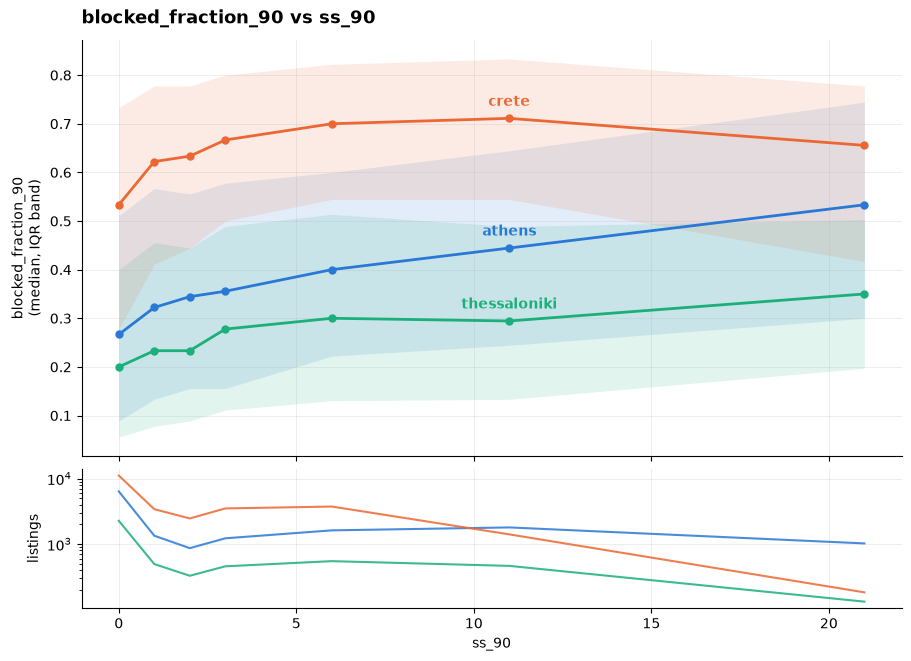

In [12]:
eda.plot_binned_relationship(
    ranked["ss_90"],
    ranked[LABEL],
    group=ranked["city"],
    bins=[-0.5, 0.5, 1.5, 2.5, 4.5, 8.5, 16.5, 500],
);

The staircase argues better than the correlation coefficient does, and it also shows its own
limits.

**Athens climbs smoothly and is well supported across every bin.** **Crete rises strongly through
the low-to-mid bins and dips slightly at the top — but those final bins hold very few listings**,
so that is thin evidence, not a trend reversal. **Thessaloniki is positive but flat through the
middle**, and its right-hand bins are the thinnest of the three.

**The interquartile bands are wide everywhere.** Review history shifts the *centre* of a
listing's availability but explains only a small part of the spread around it — which is the
honest visual statement of a 0.15–0.23 correlation.

And the caveat that no amount of monotonicity removes: a positive association between reviews and
blocked days is **not** evidence that blocked days are booked days. Hosts block for personal use,
maintenance and seasonal closure, and nothing in this data separates those from demand.

## 4. Where does the signal come from?

§3 established that the label points the right way, modestly. This section asks *why it is not
stronger*, and the answer changes what may be claimed for it.

**What the two tables below show.** First, how many listings sit in each age cohort, per city
— context for everything after it. Second, the mean label within each cohort. If listing age had
nothing to do with availability, the second table would be flat.

In [13]:
display(ranked.groupby(["city", "cohort"]).size().unstack("cohort")[COHORTS].reindex(CITIES))
display(
    ranked.pivot_table(index="city", columns="cohort", values=LABEL, aggfunc="mean")[COHORTS]
    .reindex(CITIES)
    .round(3)
)

cohort,never reviewed,new this year,established
city,,,
thessaloniki,532,1105,3051
athens,1835,2339,10045
crete,4926,3164,17687


cohort,never reviewed,new this year,established
city,,,
thessaloniki,0.215,0.269,0.326
athens,0.243,0.323,0.416
crete,0.418,0.551,0.619


**It is not flat — it is monotone in every city.** Never reviewed → new this year →
established runs 0.215 → 0.269 → 0.326 in Thessaloniki, 0.243 → 0.323 → 0.416 in Athens,
0.418 → 0.551 → 0.619 in Crete. And roughly 30 % of every market is new since last summer.

That is a strong hint that §3's correlation is partly a listing-age relationship wearing review
counts as a costume. A hint is not the finding, though: this shows establishment and the label
move together, not how much of §3 *survives* once establishment is held still.

**What the table below shows.** The §3 correlation table recomputed on established listings
only — the same signals, the same cities, with the cohort effect held constant by construction.
Compare it column-for-column against §3.

In [14]:
established = ranked[ranked["cohort"] == "established"].copy()

rho_by_city(established, DERIVED + SHIPPED)

,thessaloniki,athens,crete,city-demeaned,pooled
ss_90,0.097,0.153,0.135,0.144,0.078
trailing_90,0.081,0.138,0.226,0.170,0.036
trailing_30,0.118,0.148,0.185,0.150,0.080
number_of_reviews,0.124,0.173,0.180,0.170,0.037
number_of_reviews_ly,0.080,0.151,0.174,0.157,0.012
number_of_reviews_ltm,0.070,0.141,0.184,0.155,0.019
number_of_reviews_l30d,0.118,0.148,0.185,0.150,0.080
reviews_per_month,0.106,0.154,0.177,0.157,-0.029
estimated_occupancy_l365d,0.077,0.145,0.194,0.159,0.031


**A third to two-fifths of the correlation is establishment — and the rest survives.** The
same-season window falls from 0.150 / 0.226 / 0.233 to **0.097 / 0.153 / 0.135**, and every
other signal drops the same way; none flips sign. So a large share of "reviews predict blocking"
was really "established listings are more blocked" — but among listings of comparable age a
positive pull remains, on every signal, in every city.

This also retro-explains the weakest row of the §3 table. `reviews_per_month` was the poorest
signal there precisely because it is the one that normalises tenure away — it divides the count
by how long the listing has been live, discarding exactly the component doing the most work. And
the diagnosis checks out here: within a fixed cohort, where there is no tenure left to discard,
it pulls level with the other signals.

Establishment is not the end of it, though. If the label were *only* listing age, then within
the established cohort it would be noise — and it is not.

**What the table below shows.** Established listings split into rating terciles within their own
city. Three blocks: the mean label per band across all established listings, the same restricted
to listings with **at least 10 reviews**, and the median review count per band. The third block
exists to explain the second — a rating backed by six reviews is noise wearing a number.

In [15]:
established["rating_band"] = established.groupby("city", observed=True)[
    "review_scores_rating"
].transform(lambda s: pd.qcut(s.rank(method="first"), 3, labels=["low", "mid", "high"]))

stable = established[established["number_of_reviews"] >= 10]

pd.concat(
    {
        "all established": established.pivot_table(
            index="city", columns="rating_band", values=LABEL, aggfunc="mean", observed=True
        ),
        ">= 10 reviews": stable.pivot_table(
            index="city", columns="rating_band", values=LABEL, aggfunc="mean", observed=True
        ),
        "median reviews (ungated)": established.pivot_table(
            index="city",
            columns="rating_band",
            values="number_of_reviews",
            aggfunc="median",
            observed=True,
        ),
    },
    axis=1,
).reindex(CITIES).round(3)

all established               >= 10 reviews               median reviews (ungated)            
rating_band              low    mid   high           low    mid   high                      low   mid  high
city                                                                                                       
thessaloniki           0.248  0.340  0.390         0.245  0.344  0.412                     28.0  58.0  26.0
athens                 0.385  0.424  0.437         0.383  0.430  0.470                     28.0  72.0  32.0
crete                  0.563  0.669  0.627         0.587  0.675  0.685                     18.0  37.0   7.0

**Quality orders the cohort.** With a stable rating, the mean label rises across terciles in
every city, and the gradient is steepest exactly where §3 was weakest: Thessaloniki runs
0.248 → 0.340 → 0.390. Its poorly-rated established listings sit at **0.248** — *below* the
**0.269** of its brand-new ones — so a year of tenure with weak reviews is worth less than no
track record at all.

**The gate is doing real work, and the third block shows why.** Ungated, Crete looks non-monotone
(mid 0.669 above high 0.627) — but its "high" band has a median of **7** reviews against 37 in
the middle band. That band is full of thin histories holding noisy 5.0s. Gate at ten reviews and
every city becomes monotone. The wobble was noise in the instrument, not a failure of the
relationship.

**What the table below shows.** Within the same stable-rating population, the correlation
against *quality* (`review_scores_rating`) beside the correlation against *volume*
(`number_of_reviews`), with the sample size. The point is the ordering of the cities, not the
size of either column.

In [16]:
pd.DataFrame(
    {
        "rating": {
            city: spearmanr(part["review_scores_rating"], part[LABEL], nan_policy="omit").statistic
            for city, part in stable.groupby("city")
        },
        "review volume": {
            city: spearmanr(part["number_of_reviews"], part[LABEL]).statistic
            for city, part in stable.groupby("city")
        },
        "n": stable.groupby("city").size(),
    }
).reindex(CITIES).round(3)

,rating,review volume,n
thessaloniki,0.274,0.110,2445
athens,0.137,0.176,7969
crete,0.210,0.120,11822


**The city ordering inverts between the two columns.** Rating gives 0.274 / 0.137 / 0.210;
volume gives 0.110 / 0.176 / 0.120. Thessaloniki ranks first on quality and last on volume;
Athens does the reverse, and Crete sides with quality. A large liquid market ranks on
establishment and volume; a smaller or more seasonal one differentiates on quality. That
inversion is what rescues Thessaloniki, and it is not something a spurious relationship would
produce.

Rating is also the **cleaner instrument**, not merely the luckier one. Review counts are
mechanically produced by the same stays the label measures, so they are partly downstream of the
target. A listing does not score higher for being booked more.

**So the claim, in the narrowest form the evidence supports:** forward availability tracks
listing establishment first, and within the established cohort it is ordered by review quality.
Not defensible: that the label measures demand among otherwise-comparable listings, or any
phrasing along the lines of "guests prefer" — §7 explains why that one is unfixable here.

## 5. Why this label and not another?

§4 is the section a reviewer will push on: *if the label is mostly listing age, why use it?* The
answer is not that the confound is small. It is that **every alternative target available in this
data is more confounded, not less** — and that is measurable rather than arguable.

**What the two tables below show.** Four candidate targets. The first table correlates each
against raw `number_of_reviews` — high means "this is largely a review count in disguise". The
second correlates each against our label, to show which are genuinely different quantities and
which are the same thing relabelled.

In [17]:
candidates = {
    "blocked_fraction_90 (ours)": ranked[LABEL],
    "estimated_occupancy_l365d": ranked["estimated_occupancy_l365d"],
    "availability_90 (inverted)": -ranked["availability_90"],
    "number_of_reviews_ltm": ranked["number_of_reviews_ltm"],
}


def against(target: pd.Series) -> pd.DataFrame:
    return (
        pd.DataFrame(
            {
                name: {
                    city: spearmanr(
                        series.loc[part.index], target.loc[part.index], nan_policy="omit"
                    ).statistic
                    for city, part in ranked.groupby("city")
                }
                for name, series in candidates.items()
            }
        )
        .T[CITIES]
        .round(3)
    )


display(against(ranked["number_of_reviews"]).style.set_caption("rho vs raw review count"))
display(against(ranked[LABEL]).style.set_caption("rho vs our label"))

,thessaloniki,athens,crete
blocked_fraction_90 (ours),0.183000,0.279000,0.306000
estimated_occupancy_l365d,0.763000,0.813000,0.802000
availability_90 (inverted),0.184000,0.280000,0.306000
number_of_reviews_ltm,0.765000,0.814000,0.803000


,thessaloniki,athens,crete
blocked_fraction_90 (ours),1.000000,1.000000,1.000000
estimated_occupancy_l365d,0.138000,0.229000,0.285000
availability_90 (inverted),0.999000,1.000000,1.000000
number_of_reviews_ltm,0.132000,0.226000,0.279000


**This is the strongest single argument for the label, and it is not close.**

`estimated_occupancy_l365d` — Inside Airbnb's own occupancy estimate, the obvious substitute —
correlates **0.76 / 0.81 / 0.80** with raw review counts. It is a review model. Training on it
would mean learning to reproduce someone else's model, *and* it would be circular with the review
signals used to validate it in §3. `number_of_reviews_ltm` is the same story by construction.

`availability_90` inverted correlates **0.999+** with our label. It is not an alternative; it is
the same construct computed by someone else, which is exactly why §1 could use it as a check.
Adopting it would gain no independence and would cost control of the window and the anchor.

**Our label correlates 0.18 / 0.28 / 0.31 with review counts — the lowest of the four.** The
establishment confound §4 measured is real, and it is *smaller here than in anything else on
offer*. There is no signal in this data that is both forward-looking and independent of reviews,
so the question was never "is this label good" but "is this the best available, and are its
limits measured". On that question it wins.

One more version of the same challenge: *if it is establishment plus rating, why not just rank
on those two directly?*

**What the table below shows.** Established listings grouped into city × rating-band cells — the
two attributes that §4 showed matter most — with the count, mean and standard deviation of the
label inside each cell. If age and rating determined the label, the within-cell spread would be
small.

In [18]:
cells = established.groupby(["city", "rating_band"], observed=True)[LABEL].agg(
    ["size", "mean", "std"]
)
within = (cells["std"] ** 2 * cells["size"]).sum() / cells["size"].sum()
explained = 1 - within / established[LABEL].var()

print(f"label std across established listings : {established[LABEL].std():.3f}")
print(f"mean std within a city x rating cell  : {cells['std'].mean():.3f}")
print(f"share of variance the cells explain   : {explained:.1%}")
cells.round(3)

label std across established listings : 0.281
mean std within a city x rating cell  : 0.259
share of variance the cells explain   : 18.4%


size   mean    std
city         rating_band                    
athens       low          3348  0.385  0.281
             mid          3348  0.424  0.265
             high         3349  0.437  0.279
crete        low          5896  0.563  0.256
             mid          5895  0.669  0.213
             high         5896  0.627  0.245
thessaloniki low          1017  0.248  0.252
             mid          1017  0.340  0.262
             high         1017  0.390  0.281

**City and rating band together explain about 18 % of the label's variance among established
listings.** The within-cell standard deviation is 0.259 against 0.281 overall — the cells barely
narrow it.

So the label is emphatically *not* a restatement of age and rating. It carries availability
information those attributes do not, which is the thing a ranker is meant to learn. What this
does **not** settle is how much of that residual is signal rather than host idiosyncrasy — and
that is a question a correlation cannot answer. Phase 3 answers it properly, by freezing a
review-count baseline before training and reporting whether the model beats it.

## 6. What this costs downstream

Grading is where the label stops being a measurement and becomes a training target, so the
label's shape and its cohort bias both land here. Two decisions do the work, and each has a
tempting answer that is wrong: **which population a listing is graded against**, and **where the
cuts fall**. This section shows the evidence for both rather than asserting them.

Start with the partition, because it constrains the scheme. The obvious move is to grade within
`city × room type × price tier` — control for the market, the product and the price point, so a
grade means "in demand *for what it costs*". It fails, and not marginally.

A query group is the set of listings LambdaMART actually compares:
`city × neighbourhood × room type × capacity tier`. If the grading partition is a **coarsening**
of that key, every listing in a group sits in the same partition cell, so the grade is a monotone
step function of the label *inside the group* — a higher label can never receive a lower grade.
If the partition **cross-cuts** the key, two listings in one group were quantiled against
different populations, and their grade order can oppose their label order.

**What the table below shows.** For each candidate partition, how many of the 516 query groups
contain at least one pair whose grades run backwards against their labels. Zero is the only
acceptable number, because those pairs are what the ranker is trained to reproduce.

In [19]:
ranked["price_tier"] = ranked.groupby("city", observed=True)["price"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 3, labels=False)
)

CANDIDATE_PARTITIONS = {
    "city": ["city"],
    "city x room_type  (chosen)": ["city", "room_type"],
    "city x room_type x capacity_tier": ["city", "room_type", "capacity_tier"],
    "city x room_type x price_tier": ["city", "room_type", "price_tier"],
    "city x price_tier": ["city", "price_tier"],
}
group_positions = list(ranked.groupby(QUERY_GROUP, observed=True).indices.values())
label_values = ranked[LABEL].to_numpy()


def inverted_groups(grades: pd.Series) -> int:
    """Query groups where sorting by label leaves the grades not weakly increasing."""
    values = grades.to_numpy()
    return sum(
        bool(np.any(np.diff(values[pos][np.argsort(label_values[pos], kind="stable")]) < 0))
        for pos in group_positions
        if len(pos) > 1
    )


partition_report = pd.DataFrame(
    {
        name: {
            "cells": ranked.groupby(cols, observed=True).ngroups,
            "query groups inverted": inverted_groups(assign_grades(ranked, partition_cols=cols)[0]),
        }
        for name, cols in CANDIDATE_PARTITIONS.items()
    }
).T
partition_report["of groups"] = len(group_positions)
partition_report

/var/folders/ks/037drkhd42324wgwpk_m9_940000gn/T/ipykernel_21304/2921765211.py:30: UserWarning: 1 partition cell(s) had 30+ rows above the atom but could not be cut into 4 quantiles on value, so they were graded within ['city'] instead: [('athens', 'Hotel room', '3-4')]
  "query groups inverted": inverted_groups(assign_grades(ranked, partition_cols=cols)[0]),


,cells,query groups inverted,of groups
city,3,0,516
city x room_type (chosen),11,0,516
city x room_type x capacity_tier,41,0,516
city x room_type x price_tier,29,163,516
city x price_tier,9,168,516


**Every coarsening scores zero; the two price partitions do not.** That is not a lucky
measurement — for a coarsening it is provable, and the table is here to confirm the code agrees
with the proof. `city × room_type × price_tier` corrupts the target in 163 query groups holding
39,801 listings — 89 % of the ranked population: in each one, some listing with *lower* forward
demand is handed a *higher* relevance grade than a competitor it is ranked directly against.

Price never earned its place anyway. Its mean-label spread across tiers is the smallest of every
candidate dimension — 0.032 / 0.033 / 0.065 against 0.090 / 0.199 / 0.299 for neighbourhood and
0.027 / 0.222 / 0.146 for room type — Spearman(price, label) within city is 0.047–0.108 and
collapses to −0.058…+0.109 once capacity is held fixed, with the sign flipping between cities.
The decile curve is not even monotone: Athens is U-shaped. **So the partition is
`city × room_type`**, and no quantity derived from price touches the target at any point.

Capacity tier passes the same test, and is left out for a weaker but sufficient reason: it adds
nothing on top of room type. The warning printed above is the second half of that answer —
splitting 11 cells into 41 leaves one (Athens hotel rooms sleeping 3–4) with enough rows to clear
the minimum but too concentrated to cut into quartiles at all, so it has to be graded against its
city anyway. Fragmenting the partition buys precision it cannot spend.

**What the table below shows.** Grade shares under four schemes, plus what each does to the two
things grading can silently break: cold-start listings buried at the bottom, and identical labels
receiving different grades. Schemes A, B and F are counterfactuals implemented here; **E is the
shipped `assign_grades`**, and its last row is the same scheme cutting on the label's *value*
rather than its rank.

In [20]:
def rank_cut(frame: pd.DataFrame, mask: pd.Series, bins: int, offset: int) -> pd.Series:
    """Quantile the masked rows within partition, breaking ties by row order."""
    subset = frame[mask]
    return (
        subset.groupby(["city", "room_type"], observed=True)[LABEL].transform(
            lambda s: pd.qcut(s.rank(method="first"), bins, labels=False, duplicates="drop")
        )
        + offset
    )


def counterfactual(scheme: str) -> pd.Series:
    """Rejected alternatives, so they live here rather than in `label.py`."""
    grade = pd.Series(np.nan, index=ranked.index)
    at_zero, at_one = ranked[LABEL].eq(0.0), ranked[LABEL].eq(1.0)
    if scheme == "A pure quintile":
        grade[:] = rank_cut(ranked, ranked[LABEL].notna(), 5, 0)
    elif scheme == "B both atoms":
        grade[at_zero], grade[at_one] = 0, 4
        grade[~at_zero & ~at_one] = rank_cut(ranked, ~at_zero & ~at_one, 3, 1)
    elif scheme == "E zero atom, rank cuts":
        grade[at_zero] = 0
        grade[~at_zero] = rank_cut(ranked, ~at_zero, 4, 1)
    elif scheme == "F one atom only":
        grade[at_one] = 4
        grade[~at_one] = rank_cut(ranked, ~at_one, 4, 0)
    return grade


ranked["grade"] = assign_grades(ranked)[0]
never_reviewed = ranked["number_of_reviews"].eq(0)
schemes = {
    name: counterfactual(name)
    for name in ["A pure quintile", "B both atoms", "E zero atom, rank cuts", "F one atom only"]
}
schemes["E as shipped (value cuts)"] = ranked["grade"]


def scheme_row(grade: pd.Series) -> pd.Series:
    shares = grade.value_counts(normalize=True).sort_index() * 100
    split = ranked.assign(g=grade).groupby(["city", "room_type", LABEL], observed=True)["g"]
    return pd.Series(
        {
            **{f"grade {i}": round(shares.get(i, 0.0), 1) for i in range(5)},
            "same label, 2+ grades %": round(split.transform("nunique").gt(1).mean() * 100, 1),
            "cold start in grade 0 %": round(grade[never_reviewed].eq(0).mean() * 100, 1),
        }
    )


pd.DataFrame({name: scheme_row(g) for name, g in schemes.items()}).T

,grade 0,grade 1,grade 2,grade 3,grade 4,"same label, 2+ grades %",cold start in grade 0 %
A pure quintile,20.0,20.0,20.0,20.0,20.0,5.8,38.6
B both atoms,3.4,31.3,31.3,31.3,2.6,3.1,8.0
"E zero atom, rank cuts",3.4,24.2,24.1,24.1,24.2,4.2,8.0
F one atom only,24.4,24.3,24.3,24.4,2.6,4.2,43.9
E as shipped (value cuts),3.4,24.6,24.1,24.4,23.4,0.0,8.0


**The entire cold-start benefit comes from the zero atom, and nothing else does.** Reserving both
atoms (B) and reserving only the zero atom (E) leave the *identical* 8.0 % of never-reviewed
listings in grade 0, against 38.6 % under plain quintiles. Scheme F is the control that proves
it: reserve only the 1.0 atom and pool the zeros, and burial goes to 43.9 % — worse than doing
nothing. Grade 0 is the lever; grade 4 is not.

Which makes reserving 1.0 pure cost, and the cost is concrete. It produces a 2.6 % top class
appearing in only 41 % of query groups against 73 % under E, and it lets a single blocked night
out of ninety decide a grade boundary — on a label where blocked is not booked. The dormancy
audit of §2 had already removed the reason scheme B was proposed: every listing now sitting at
1.0 carries a review history, so it earns the top quartile instead of needing a reserved seat.

**The last row is the tie rule, and it goes to zero rather than merely down.** Cutting on the
label's *value* — left-open, right-closed intervals — instead of on `rank(method="first")` means
every listing sharing a label value shares a grade. Under rank cuts, 5.8 % of listings share a
label that maps to more than one grade in their own cell, because the label lives on a 91-value
grid and boundaries land mid-tie; the split is then decided by row order, which is not a
property of the listing at all. Cutting on value takes that to **0 %**. The price is quartiles
that are not exactly equal — 24.6 / 24.1 / 24.4 / 23.4 rather than a forced 25 % — because a
boundary value now takes its whole tie group into the lower bin. That is the right trade: an
unequal bin is a description of the data, an arbitrary tiebreak is noise.

Be precise about what scheme E does **not** fix. Far fewer cold-start listings are buried, but
their over-representation *ratio* is slightly worse — 2.38× the 3.4 % base rate, against 1.93×
under pure quintiles. The bucket shrank; the bias did not.

**What the table below shows.** The same schemes, but asking which cohort ends up in which grade.
Each row sums to 100 % across grades, so the question is whether a cohort is over-represented at
the bottom.

In [21]:
def grade_mix(grade: pd.Series) -> pd.DataFrame:
    counts = (
        ranked.assign(g=grade)
        .pivot_table(index="cohort", columns="g", values="id", aggfunc="size")
        .reindex(COHORTS)
    )
    return counts.div(counts.sum(axis=1), axis=0) * 100


pd.concat(
    {
        "A pure quintile": grade_mix(schemes["A pure quintile"]),
        "E as shipped": grade_mix(ranked["grade"]),
    },
    axis=1,
).round(1)

A pure quintile                         E as shipped                        
g                          0.0   1.0   2.0   3.0   4.0          0.0   1.0   2.0   3.0   4.0
cohort                                                                                     
never reviewed            38.6  21.6  16.6  13.2  10.0          8.0  39.8  22.7  17.3  12.1
new this year             22.7  22.7  21.2  18.3  15.1          4.0  28.0  27.0  22.9  18.1
established               15.0  19.0  20.5  22.0  23.4          2.1  20.3  23.9  26.4  27.3

**Under pure quantile grading the label buries cold-start listings.** Never-reviewed listings land
in grade 0 at 38.6 % against a 20 % base rate. That is the establishment bias of §4, written into
the *training target* before any feature or model exists — a ranker trained on it learns "new
means irrelevant" from the labels themselves. Scheme E cuts that to 8.0 %, so 92 % of them land
somewhere in the contention range instead.

The empty top-right cell is by construction: a never-reviewed listing at exactly 1.0 *is* the
inactive filter, so none survives to reach the top of the scale.

**What the table below shows.** Group health under each scheme, for the query groups LambdaMART
will actually see — not the grading partition. A group whose rows all carry one grade produces no
gradient, so it is dead weight; a singleton is worse.

In [22]:
def group_health(grade: pd.Series) -> pd.Series:
    graded = ranked.assign(g=grade).groupby(QUERY_GROUP, observed=True)["g"]
    sizes, distinct = graded.size(), graded.nunique()
    return pd.Series(
        {
            "groups": len(sizes),
            "singletons": int(sizes.eq(1).sum()),
            "zero-variance (size > 1)": int(((distinct == 1) & (sizes > 1)).sum()),
            "mean distinct grades": round(distinct[sizes > 1].mean(), 2),
            "groups reaching grade 4 %": round(graded.max().eq(4).mean() * 100, 1),
        }
    )


pd.DataFrame(
    {
        "A pure quintile": group_health(schemes["A pure quintile"]),
        "B both atoms": group_health(schemes["B both atoms"]),
        "E as shipped": group_health(ranked["grade"]),
    }
)

,A pure quintile,B both atoms,E as shipped
groups,516.00,516.00,516.00
singletons,71.00,71.00,71.00
zero-variance (size > 1),15.00,29.00,27.00
mean distinct grades,4.11,3.67,3.91
groups reaching grade 4 %,72.90,41.30,72.90


**Scheme E's cost, stated plainly:** zero-variance groups rise from 15 to 27 of 516 against pure
quintiles, and mean distinct grades per multi-row group falls from 4.11 to 3.91. Those groups
contribute nothing to the gradient. It is a real cost and it is the price of reserving any atom.

It is also most of the argument scheme B lost. B pays more of the same cost — 29 zero-variance
groups, 3.67 distinct grades — buys nothing extra for it, and its top grade reaches 41 % of
groups against E's 73 %. E is where the trade is worth making.

Phase 2 pays much of the remainder back: the minimum-group-size rule with a drop-the-neighbourhood
fallback takes zero-variance groups to 10 of 399, recovers mean distinct grades to 4.27, and lifts
grade-4 coverage to 86 %. That is a grouping decision, measured separately, but it is why this
cost was accepted rather than treated as decisive.

Two cells fall below the 30-row minimum and are graded against their whole city instead — Athens
and Crete shared rooms, 32 listings between them. They are pooled with the city population rather
than with each other, which matters: quantiling five listings among themselves would spread them
across all four grades on no evidence, which is exactly what the minimum exists to prevent.

## 7. Does the temporal split actually hold?

Everything above assumes a clean division: **features are what was known at T, the label is what
the calendar says about after T.** That is the project's leakage guarantee, and it is worth
checking rather than asserting — a proxy that passed every test in §1–§6 would still be worthless
if its features could see into the window.

The guarantee has a specific shape here. Listing attributes come from `listings.csv`, captured at
`scrape_date`; the label comes from calendar rows dated T onward. So the split holds exactly when
`scrape_date <= T` for every listing. It is not an assumption about the data, it is a property
that can be counted.

**What the table below shows.** How many listings were scraped *after* their own label window
opened, by city and by how many days — and, for those that were, whether the one attribute that
could plausibly have moved in the gap actually did.

In [23]:
ranked["scrape_lag_days"] = (ranked["scrape_date"] - ranked["T"]).dt.days
breached = ranked[ranked["scrape_lag_days"] > 0]

display(
    pd.DataFrame(
        {
            "listings": ranked.groupby("city").size(),
            "scraped after T": breached.groupby("city").size(),
        }
    )
    .reindex(CITIES)
    .fillna(0)
    .astype(int)
    .assign(**{"share %": lambda d: (d["scraped after T"] / d["listings"] * 100).round(3)})
)

print(f"lag in days: {breached['scrape_lag_days'].value_counts().sort_index().to_dict()}")
print(
    f"of those {len(breached)}, listings with a review dated after T: "
    f"{int((breached['last_review'] > breached['T']).sum())}"
)

,listings,scraped after T,share %
city,,,
thessaloniki,4688,0,0.000
athens,14219,5,0.035
crete,25777,21,0.081


lag in days: {1: 13, 2: 13}
of those 26, listings with a review dated after T: 0


**26 listings out of 44,684 — 0.06 % — had their attributes recorded one or two days after their
label window opened.** Thirteen at one day, thirteen at two, all in Athens and Crete, where the
scrape ran across four calendar days. Their attributes therefore describe a state 1–2 days into a
90-day window rather than at its edge.

**The breach is nominal, not material, and that is measurable rather than reassuring-sounding.**
Structural attributes — room type, capacity, neighbourhood — cannot change in two days. The one
class of attribute that could is review-derived: a review landing inside the gap would raise
`number_of_reviews` and shift the rating, and those are exactly the features §3 and §4 lean on.
Not one of the 26 has a review dated after its T. Nothing moved.

They are **kept, and named here.** Excluding them would mean a fifth filter rule for 26 rows, and
row exclusion in this project lives in `filters.py` with a stated threshold and a reported count —
not in a quiet drop. Their mean label is 0.527 against 0.482 overall, which is Crete being
over-represented among them, not a property of the breach.

**The larger caveat is not this one.** It is that a single snapshot cannot supply a train/test
split *in time* at all. What this section establishes is **feature provenance**: no feature is
computed from data that postdates the label window's opening. That is a real and checkable
guarantee, and it is the one the write-up should claim. It is not the same as evaluating on a
later period, and Phase 3's holdout — a grouped split on `cluster_id`, so near-twin listings
cannot straddle it — is a separate decision with no second time period available to it.
Conflating the two would be precisely the overclaim this notebook exists to avoid.

## 8. Limitations

Stated once, plainly, and not re-apologised for elsewhere.

- **Blocked ≠ booked.** A listing may be blocked for personal use, maintenance or seasonal
  closure. Nothing in this data separates those from demand. This is why the label is called a
  proxy everywhere and never "bookings".
- **The identification limit.** "Less blocked" reads two ways that cannot be told apart here:
  guests avoided it, or the host left it open *because* it does not sell. There are no bookings,
  no impressions and no price history. For **ranking** this does not matter — either way the
  listing is less occupied. For a claim about **demand** it does.
- **One season.** The window is 90 days of one summer, chosen because peak season is when
  blocked ≈ booked is most credible. Whether the relationship holds in February is untested.
- **Ratings are ceiling-compressed** — the 95th percentile is 5.0 in all three cities. §4 reports
  bands and orderings only; a slope in rating units would imply a scale the data does not have.
- **Rating is undefined for never-reviewed listings**, so they and the rated cohort never sit on
  one axis. The leftmost cohort column is a different measurement regime.
- **One snapshot.** The temporal split is a guarantee about feature provenance, not a train/test
  split in time — there is no second period available. §7 counts the one breach of the
  provenance guarantee: 26 listings scraped 1–2 days after their window opened, none of which
  gained a review in the gap.
- **Survivorship**, which cuts the other way: the worst listings delisted before the scrape, so
  the measured gradients are attenuated rather than inflated.
- **Grade 0 is not comparable across cities.** It is an absolute criterion — zero blocked nights
  in ninety — while grades 1–4 are within-partition quantiles. So it holds 7.1 % of Thessaloniki
  against 2.0 % of Crete. That is defensible, because selling nothing in a peak-season quarter
  means the same thing in every market, but it is a deliberate departure from the reason the rest
  of the scale is graded within city, and it is not an accident of the cut points.
- **Cold-start listings remain over-represented in grade 0** at 2.38× the base rate. §6 reduces
  how many are buried by nearly fivefold; it does not make the bottom grade unbiased.
- **The top grade is thin.** Grade 4 appears in 72.9 % of query groups on the raw key, 86.0 % after
  Phase 2's minimum-size fallback. NDCG normalises within group so a group topping out at grade 3
  is well defined, but the metric leans on a class a quarter of groups never show.

## Verdict

**The gate passes, on the narrow claim.** Every review signal correlates positively with the
label in every city, before and after filtering — 54 of 54 combinations, none negative. The
computation is independently verified at 99.96 %+. The relationship is modest in absolute terms
and runs substantially through listing establishment, and both of those are measured here rather
than discovered later.

**What the label measures:** forward availability, which tracks listing establishment first and,
within the established cohort, is ordered by review quality. Establishment accounts for a third
to two-fifths of the raw correlation, and city and rating together explain roughly 18 % of the
label's variance among established listings — so it is not a restatement of the attributes, and
it carries availability information a ranker can learn.

**What the filters bought:** the dormancy audit removed 1,503 withdrawn listings that sat on the
label's maximum — cross-examined in §2 against the review file, which the rule never reads — so
the top of the label no longer rewards being abandoned. The 1.0 atom now holds only listings
with review histories that reopen later in the year, and the before/after table in §3 shows how
much of the raw attenuation those listings were causing.

**Why this label:** because no signal in this data is both forward-looking and independent of
reviews, and every alternative is more review-derived than this one — 0.76–0.81 against
0.18–0.31. The confound is real and it is the smallest available.

**What grading does with it:** the partition is a coarsening of the query-group key, so a
higher label can never receive a lower grade than a listing it is ranked against — checked, not
assumed. The scale reserves the zero atom and quartiles everything above it, which cuts
cold-start burial from 38.6 % to 8.0 %, and cuts land on the label's value, so identical listings
can no longer be separated by row order.

**What is still open, and where it gets answered:** whether the model beats simply ranking by
review count is a Phase 3 question, settled by a baseline frozen before training rather than by
any correlation here. The establishment bias is now written into the grades (§6) and quantified;
Phase 5's fairness pass measures the model against *that* bias rather than against neutral.

**The split:** features are as-of-T attributes, the label is the calendar after T, and §7 counts
the exceptions rather than assuming there are none — 26 listings (0.06 %) scraped one or two days
late, none of which gained a review in the gap. That is a provenance guarantee, not a split in
time; one snapshot cannot provide the latter.

**What Phase 2 inherits**

- the ranked population (44,684 listings) and its per-city, per-rule filter counts
- the label, its two atoms, and grades 0–4 built from the zero atom plus quartiles
- the review-window machinery, which is a feature source as well as a validator
- listing age and rating reliability as things the model must be given **explicitly**, so the
  bias they carry can be measured rather than silently inherited